In [7]:
with open("/path/to/lfw/lfw_ann.txt", "r") as f:
    lines = f.readlines()
lines = [line.strip().split() for line in lines]
lines = [i for i in lines if i[0] == '1'][:1000]

In [14]:
import cv2
from insightface.app import FaceAnalysis
import torch
import numpy as np
app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))

def compare_face_insight(image_path, image_path_2):
    try:
        image = cv2.imread(image_path)
        faces = app.get(image)
        faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        image = cv2.imread(image_path_2)
        faces = app.get(image)
        faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        cos_sim = torch.nn.functional.cosine_similarity(faceid_embeds_1, faceid_embeds_2).item()
        return cos_sim
    except Exception as e:
        print("Error in compare_face_insight:", e)
        return None

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w

In [16]:
import tqdm
sims = []
for idx, line in enumerate(tqdm.tqdm(lines)):
    fn = ["/path/to/lfw/" + line[1], "/path/to/lfw/" + line[2]]
    sim = compare_face_insight(fn[0], fn[1])
    if sim is not None:
        sims.append(sim)


100%|██████████| 1000/1000 [00:40<00:00, 24.60it/s]


(array([ 1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,
         0.,  1.,  0.,  1.,  0.,  3.,  4.,  2.,  2.,  8.,  5., 15., 12.,
        12., 14., 24., 29., 62., 58., 64., 64., 75., 77., 85., 79., 62.,
        57., 57., 43., 24., 18., 17., 10.,  6.,  4.,  1.,  1.]),
 array([0.02537777, 0.04369309, 0.06200841, 0.08032374, 0.09863906,
        0.11695438, 0.1352697 , 0.15358502, 0.17190034, 0.19021566,
        0.20853098, 0.2268463 , 0.24516162, 0.26347694, 0.28179226,
        0.30010758, 0.3184229 , 0.33673823, 0.35505355, 0.37336887,
        0.39168419, 0.40999951, 0.42831483, 0.44663015, 0.46494547,
        0.48326079, 0.50157611, 0.51989143, 0.53820675, 0.55652207,
        0.5748374 , 0.59315272, 0.61146804, 0.62978336, 0.64809868,
        0.666414  , 0.68472932, 0.70304464, 0.72135996, 0.73967528,
        0.7579906 , 0.77630592, 0.79462124, 0.81293657, 0.83125189,
        0.84956721, 0.86788253, 0.88619785, 0.90451317, 0.92282849,
        0.94114381]),
 <BarContainer

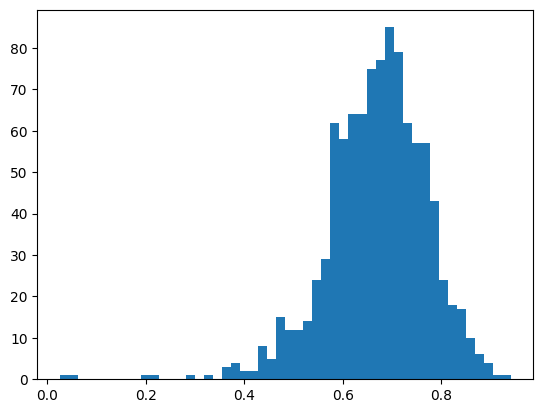

In [ ]:
import pylab
pylab.hist(sims, bins=50)